#Setup

In [1]:

%pip install --quiet seaborn ydata_profiling==4.12.2 git+https://github.com/pycaret/pycaret.git@master


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
# upload data
from google.colab import files
uploaded = files.upload()

Saving rooster_a2_discount.xlsx to rooster_a2_discount.xlsx


In [3]:
# format figures for display in Canvas

import seaborn as sns

sns.set_theme(style="white", rc={"figure.figsize": (12, 6)})
sns.set_context("notebook", font_scale=1.25, rc={"lines.linewidth": 2.5})

# in Colab, if this cell fails with
# "ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject"
# first try restarting the runtime.
# To restart the runtime, use the menu: Runtime menu -> Restart runtime
# or use the keyboard shortcut Ctrl-M then . (period) and confirm. Mac: ⌘-M then . (period).
# Then re-run this cell.

## Data loading

In [4]:
import pandas as pd

orders = pd.read_excel("/content/rooster_a2_discount.xlsx", sheet_name="orders")
products = pd.read_excel("/content/rooster_a2_discount.xlsx", sheet_name="products")
customers = pd.read_excel("/content/rooster_a2_discount.xlsx", sheet_name="customers")
metadata = pd.read_excel("/content/rooster_a2_discount.xlsx", sheet_name="metadata")

In [5]:
# check that the data is loaded correctly

metadata_dict = {r[0]: r[1] for r in metadata.values}
print(f"""
Assessment scenario is {metadata_dict["Scenario"]}.
The data was extracted using schema version {metadata_dict["Schema version"]}.
""")
metadata


Assessment scenario is Discount strategy (5).
The data was extracted using schema version 22804-02.



,Field,Value
0,Scenario,Discount strategy (5)
1,Products,"(285, 13)"
2,Orders,"(6177, 17)"
3,First order date,2023-10-09
4,Last order date,2024-10-31
5,Schema version,22804-02


#Clean data for Tableau

In [6]:
# Duplicate and clean  columns
orders['discount_amount_cleaned'] = orders['discount_amount'].fillna(0)
orders['discount_amount_tax_cleaned'] = orders['discount_amount_tax'].fillna(0)

# Display
display(orders[['discount_amount', 'discount_amount_cleaned', 'discount_amount_tax', 'discount_amount_tax_cleaned']].head())

,discount_amount,discount_amount_cleaned,discount_amount_tax,discount_amount_tax_cleaned
0,NaN,0.00,NaN,0.00
1,NaN,0.00,NaN,0.00
2,NaN,0.00,NaN,0.00
3,NaN,0.00,NaN,0.00
4,41.67,41.67,8.33,8.33


In [7]:
orders['coupon_code_cleaned'] = orders['coupon_code'].fillna('non-coupon')
display(orders[['coupon_code_cleaned','coupon_code']].head())

,coupon_code_cleaned,coupon_code
0,non-coupon,NaN
1,non-coupon,NaN
2,non-coupon,NaN
3,non-coupon,NaN
4,ROOSTER,ROOSTER


In [8]:
# Export
#orders.to_excel("orders_cleaned_for_tableau.xlsx", index=False)

with pd.ExcelWriter("cleaned_data_for_tableau.xlsx") as writer:
    orders.to_excel(writer, sheet_name="orders", index=False)
    products.to_excel(writer, sheet_name="products", index=False)
    customers.to_excel(writer, sheet_name="customers", index=False)


### Pandas

In [9]:
# test pandas: add order_month and repeat_order columns to orders dataframe

import pandas as pd

# convert order_date to datetime
orders["order_date"] = pd.to_datetime(orders["order_date"])

# convert order_date to month-year
orders["order_month"] = orders["order_date"].dt.to_period("M").dt.to_timestamp()

# add an indicator for repeat orders
orders["repeat_order"] = orders["order_seq"] > 1

# get value counts for indicator
orders["repeat_order"].value_counts()

,count
repeat_order,
False,5094
True,1083


In [10]:
#print(orders["order_month"])
#print(orders["repeat_order"])
#print(orders["order_seq"])

### seaborn

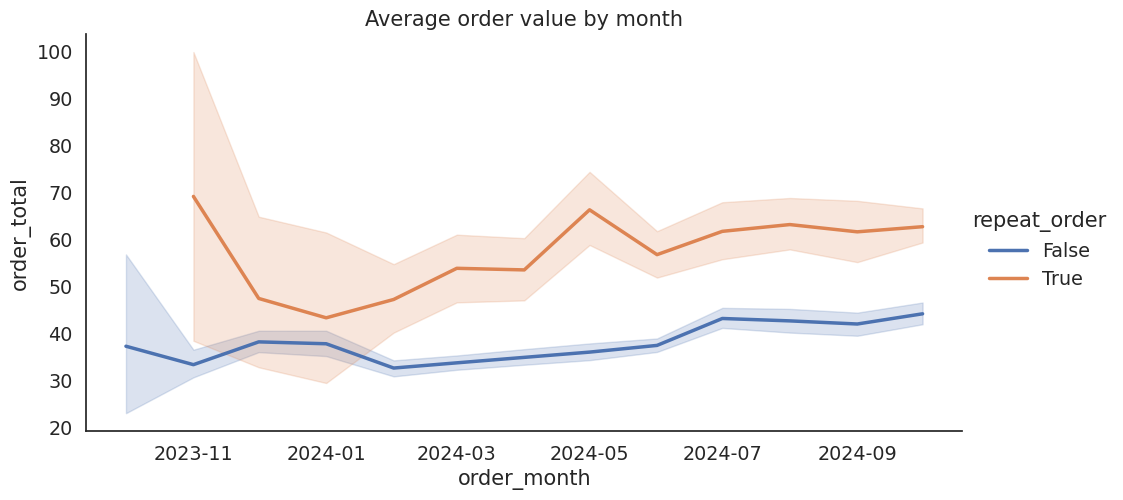

In [11]:
# test seaborn: plot average order value by month

import seaborn as sns

sns.relplot(data=orders, x="order_month", y="order_total", kind="line", hue="repeat_order", aspect=2).set(title="Average order value by month")

# Summary statistics

In [12]:
# Summary statistics
df_customers = pd.read_excel("rooster_a2_discount.xlsx", sheet_name="customers")

df_products = pd.read_excel("rooster_a2_discount.xlsx", sheet_name="products")


df_customers["customer_total_spent"].describe()


,customer_total_spent
count,5090.000000
mean,51.288446
std,40.691163
min,0.000000
25%,20.560000
50%,40.410000
75%,56.410000
max,437.930000


In [13]:
df_orders = pd.read_excel("rooster_a2_discount.xlsx", sheet_name="orders")

df_orders[["order_subtotal","order_total","order_total_tax","order_shipping","order_refund","cart_discount","discount_amount"]].describe()

,order_subtotal,order_total,order_total_tax,order_shipping,order_refund,cart_discount,discount_amount
count,6177.000000,6177.000000,6177.000000,6177.000000,6177.000000,6177.000000,2132.000000
mean,36.139781,42.262942,4.683362,2.479783,0.009749,1.283252,3.717608
std,24.194327,25.981655,5.258879,0.905805,0.606971,3.064362,4.261202
min,8.330000,0.000000,0.000000,0.000000,0.000000,0.000000,0.690000
25%,14.900000,20.400000,0.000000,2.420000,0.000000,0.000000,1.410000
50%,33.800000,37.700000,3.370000,2.500000,0.000000,0.000000,2.110000
75%,39.900000,51.200000,8.130000,3.220000,0.000000,1.490000,5.410000
max,218.330000,259.800000,43.300000,5.000000,45.320000,83.333333,83.330000


In [14]:
df_products = pd.read_excel("rooster_a2_discount.xlsx", sheet_name="products")
df_products["price"].describe()

,price
count,285.000000
mean,43.549123
std,38.578823
min,10.000000
25%,16.900000
50%,16.900000
75%,63.600000
max,200.000000


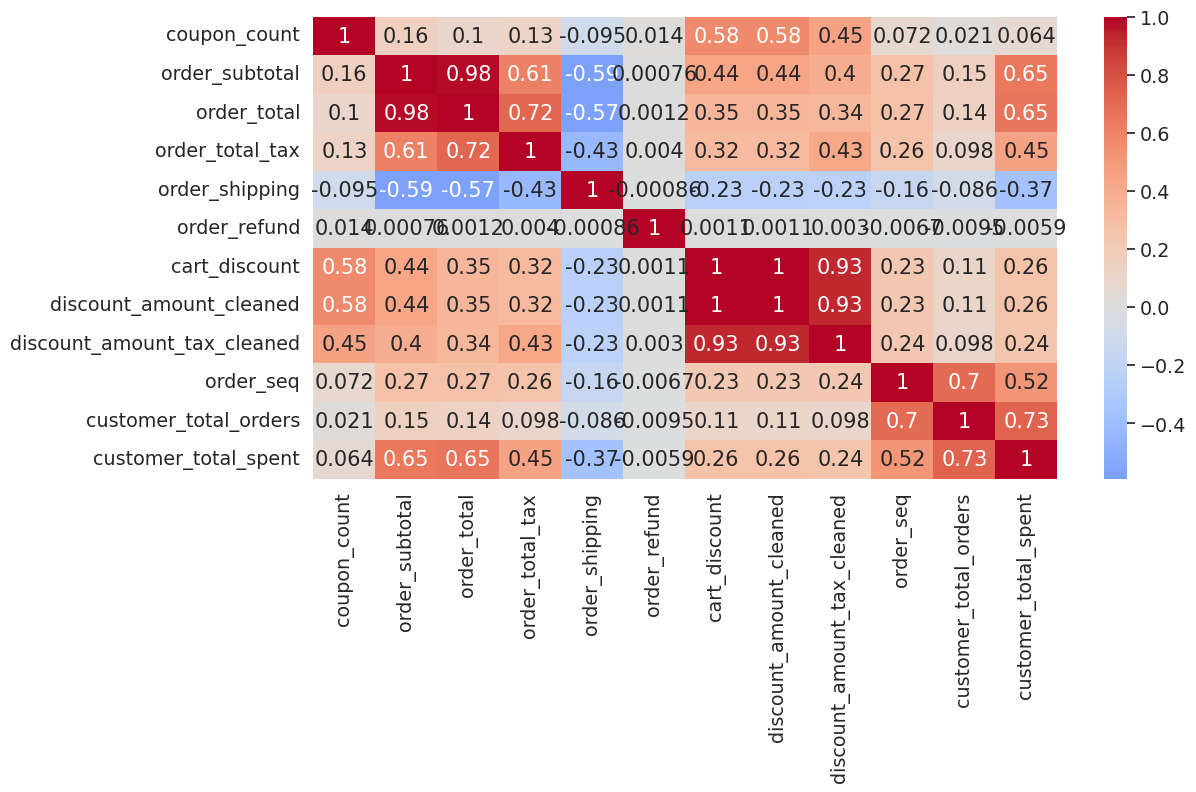

In [15]:
# Merge orders and customers
orders_customers = pd.merge(orders, customers[['customer_email', 'customer_total_orders', 'customer_total_spent','customer_first_order_date','customer_last_order_date']], on='customer_email', how='left')

# correlation matrix variables
numeric_cols = ['coupon_count','order_subtotal','order_total','order_total_tax','order_shipping','order_refund','cart_discount','discount_amount_cleaned','discount_amount_tax_cleaned','order_seq', 'customer_total_orders', 'customer_total_spent']

corr = orders_customers[numeric_cols].corr()
ax = sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)

In [16]:
# test ydata_profiling: generate report on customer data, using minimal=True to speed up the report generation

from ydata_profiling import ProfileReport

profile = ProfileReport(customers, progress_bar=False, minimal=True)
profile.to_file("original_report customers.html")

profile = ProfileReport(orders, progress_bar=False, minimal=True)
profile.to_file("original_report orders.html")

profile = ProfileReport(products, progress_bar=False, minimal=True)
profile.to_file("original_report products.html")






# Business Segment

In [17]:
# create new
orders['coupon_used'] = (orders['coupon_count'] > 0).map({True: 'Coupon', False: 'No coupon'})
orders['order_type'] = (orders['order_seq'] == 1).map({True: 'First', False: 'Repeat'})

In [18]:
print(orders['order_type'])
#print(orders['coupon_used'])

0        First
1       Repeat
2        First
3        First
4        First
         ...  
6172     First
6173     First
6174     First
6175     First
6176     First
Name: order_type, Length: 6177, dtype: object


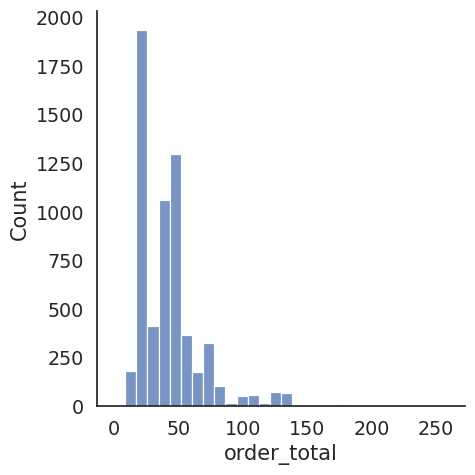

In [19]:
# order total
sns.displot(orders, x='order_total', bins=30)

<Axes: xlabel='coupon_used', ylabel='order_total'>

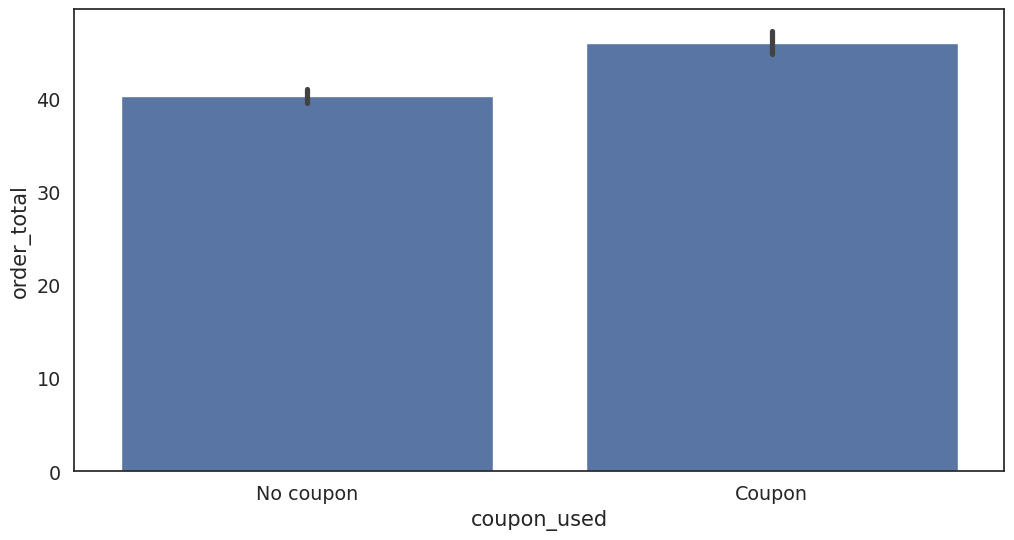

In [20]:
#coupon and non-coupon customers
sns.barplot(orders, x='coupon_used', y='order_total', estimator='mean')

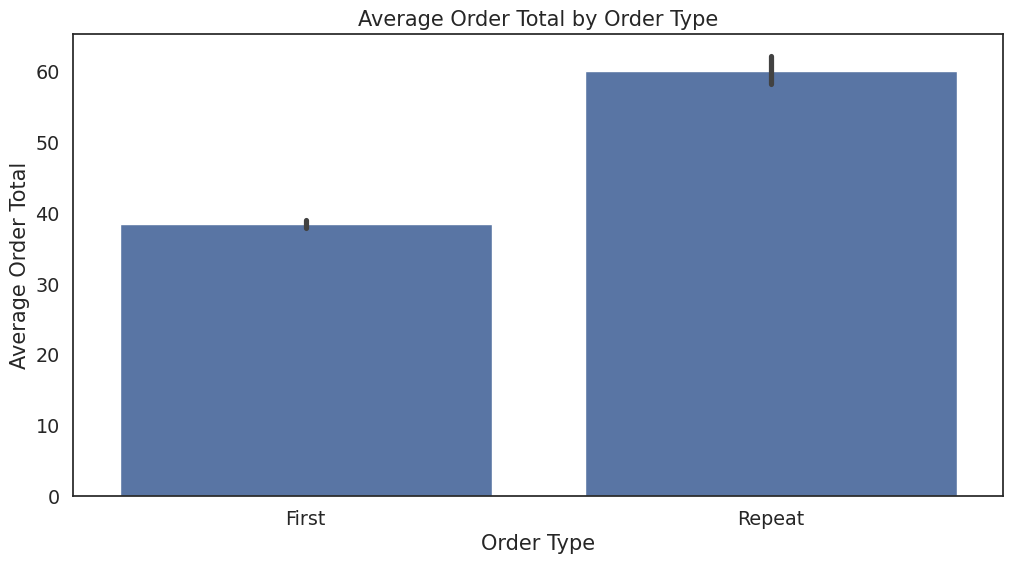

In [21]:
# compare one-teme vs repeat buyers

import matplotlib.pyplot as plt
sns.barplot(orders, x='order_type', y='order_total', estimator='mean')
plt.title('Average Order Total by Order Type')
plt.xlabel('Order Type')
plt.ylabel('Average Order Total')
plt.show()

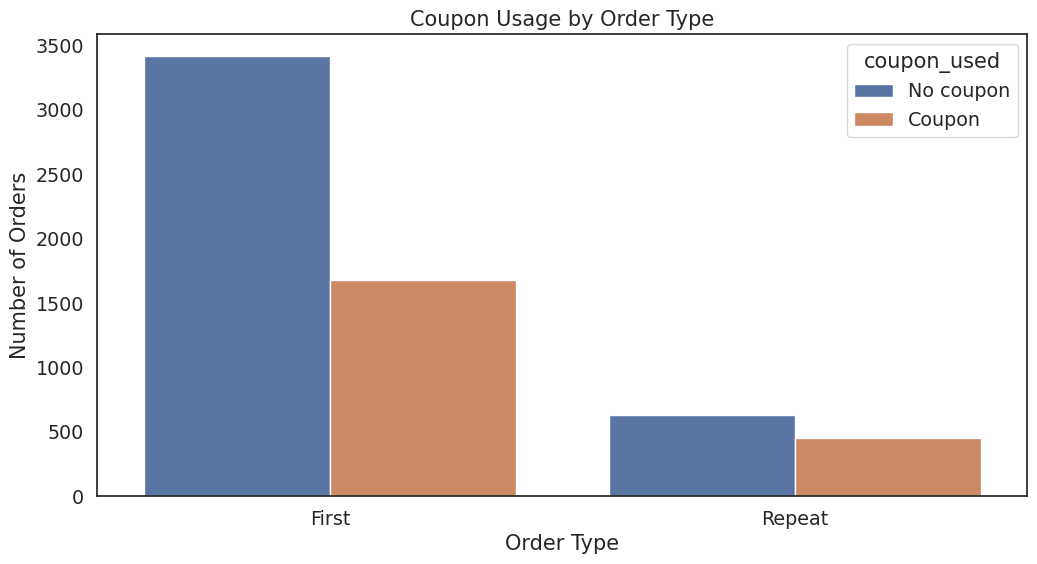

In [22]:
# Compare coupon usage between first and repeat purchases

sns.countplot(data=orders, x='order_type', hue='coupon_used')
plt.title('Coupon Usage by Order Type')
plt.xlabel('Order Type')
plt.ylabel('Number of Orders')
plt.show()

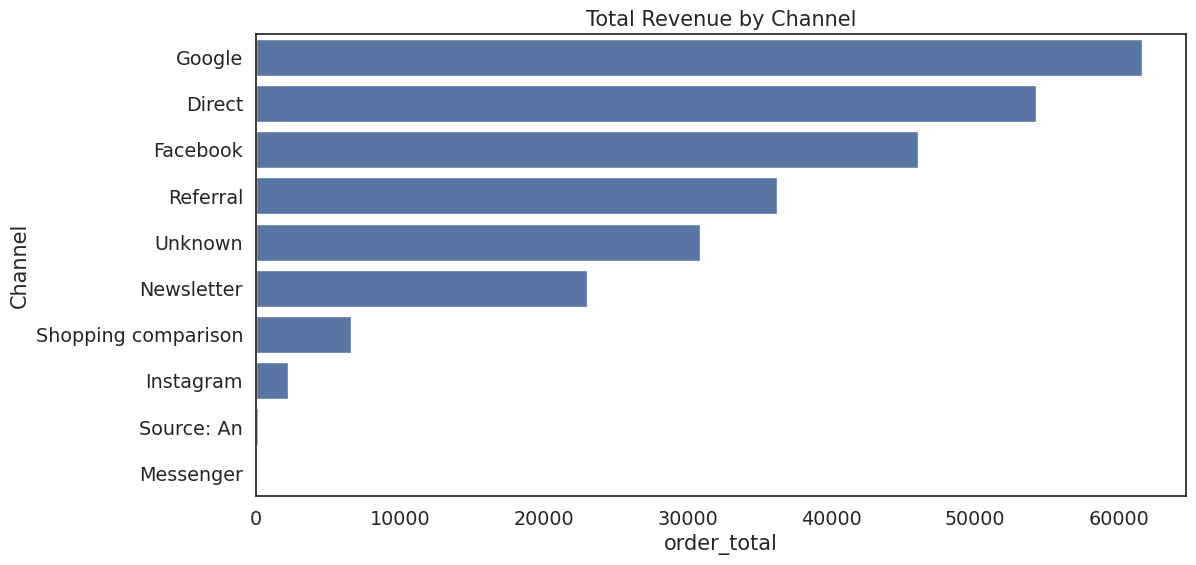

In [23]:
# Segment by Channel

rev_by_origin = orders.groupby('origin', as_index=False)['order_total'].sum().nlargest(10, 'order_total')
sns.barplot(rev_by_origin, x='order_total', y='origin')
plt.title('Total Revenue by Channel')

plt.ylabel('Channel')
plt.show()

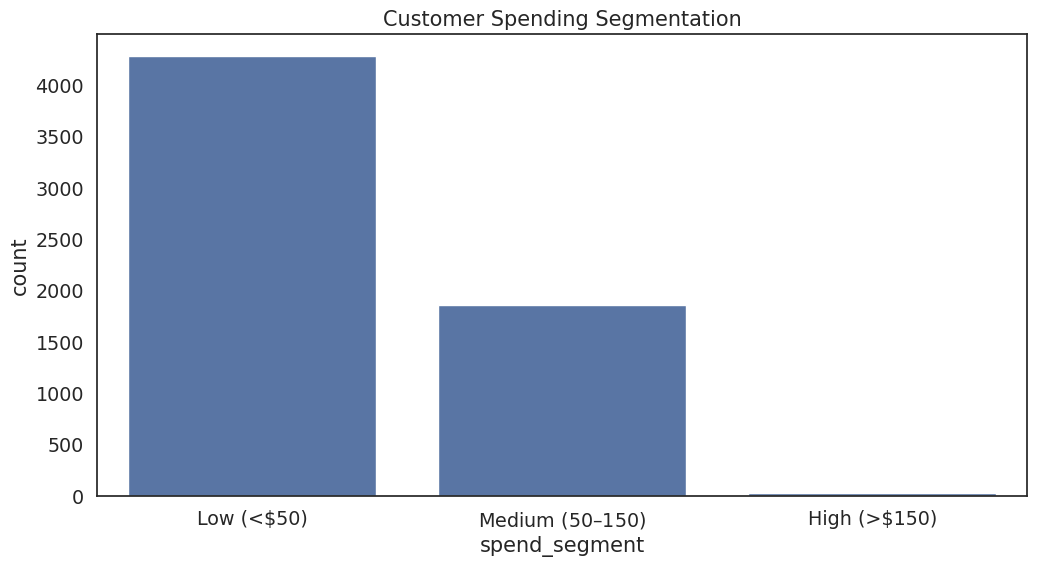

In [24]:
#Segment by Spending Lv

bins = [0, 50, 150, orders['order_total'].max()]
labels = ['Low (<$50)', 'Medium ($50–$150)', 'High (>$150)']
orders['spend_segment'] = pd.cut(orders['order_total'], bins=bins, labels=labels, include_lowest=True)
sns.countplot(orders, x='spend_segment')
plt.title('Customer Spending Segmentation')
plt.show()


Text(0.5, 1.0, 'Spending Segments by Coupon Usage')

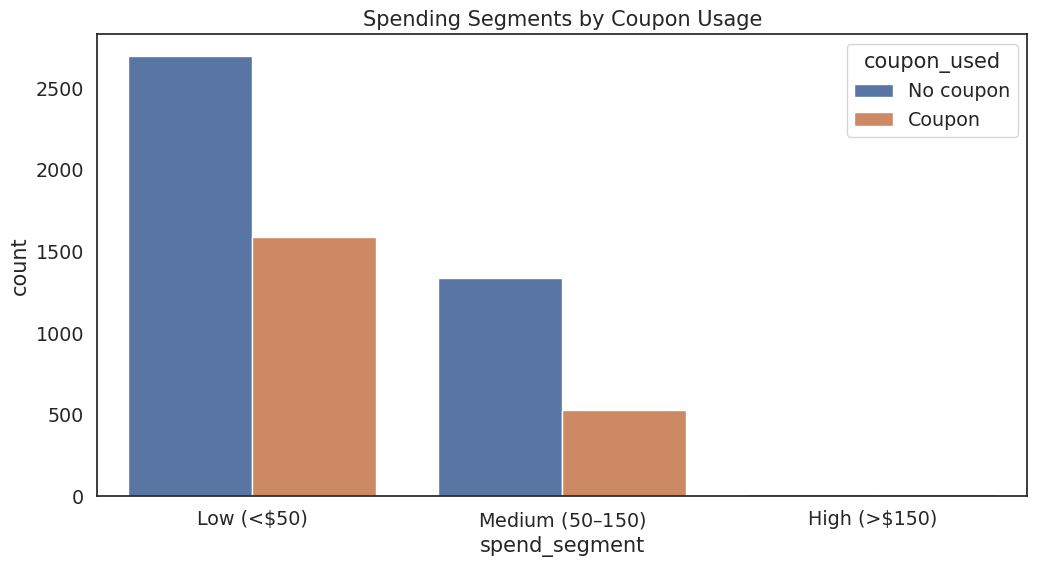

In [25]:
# coupon use by lv spending

sns.countplot(orders, x='spend_segment', hue='coupon_used')
plt.title('Spending Segments by Coupon Usage')

# Unusual patterns

In [26]:
orders[['order_total', 'discount_amount', 'order_shipping', 'order_refund']].describe()

,order_total,discount_amount,order_shipping,order_refund
count,6177.000000,2132.000000,6177.000000,6177.000000
mean,42.262942,3.717608,2.479783,0.009749
std,25.981655,4.261202,0.905805,0.606971
min,0.000000,0.690000,0.000000,0.000000
25%,20.400000,1.410000,2.420000,0.000000
50%,37.700000,2.110000,2.500000,0.000000
75%,51.200000,5.410000,3.220000,0.000000
max,259.800000,83.330000,5.000000,45.320000


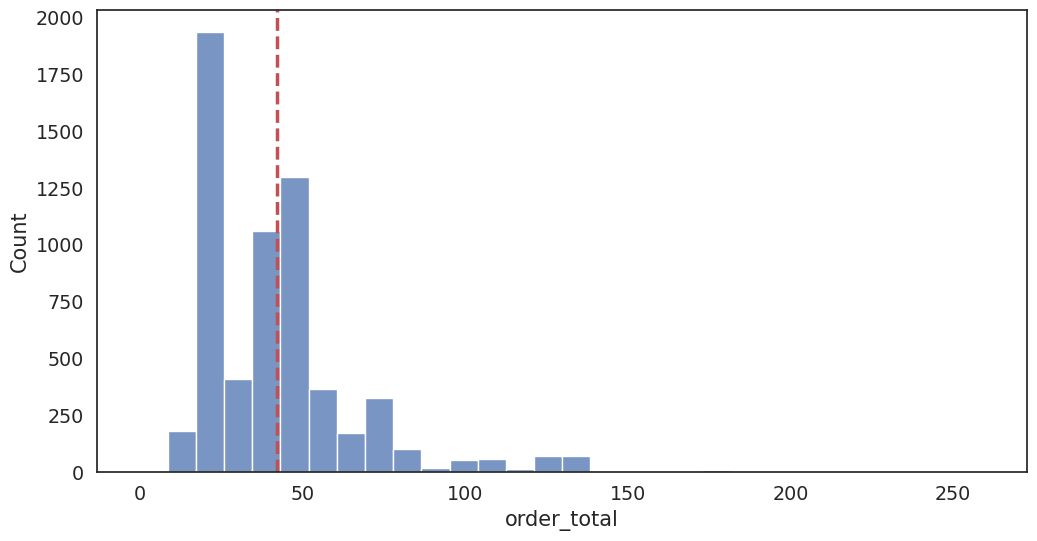

In [27]:
# Add a histogram of order_total before drawing the mean line
sns.histplot(orders, x='order_total', bins=30)

plt.axvline(orders["order_total"].mean(), color='r', linestyle='--')

<Axes: ylabel='order_total'>

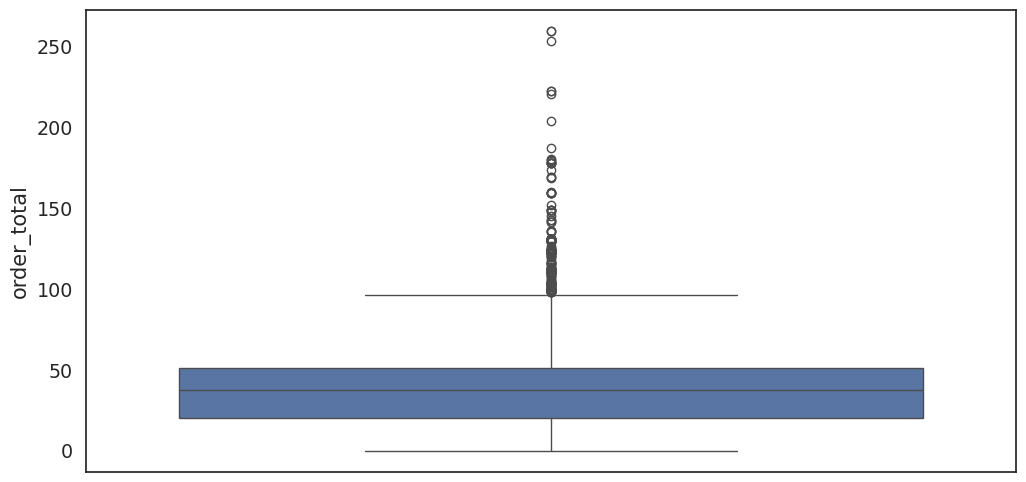

In [28]:
sns.boxplot(orders, y='order_total')

Text(0.5, 1.0, 'Relationship Between Discount Amount and Order Total')

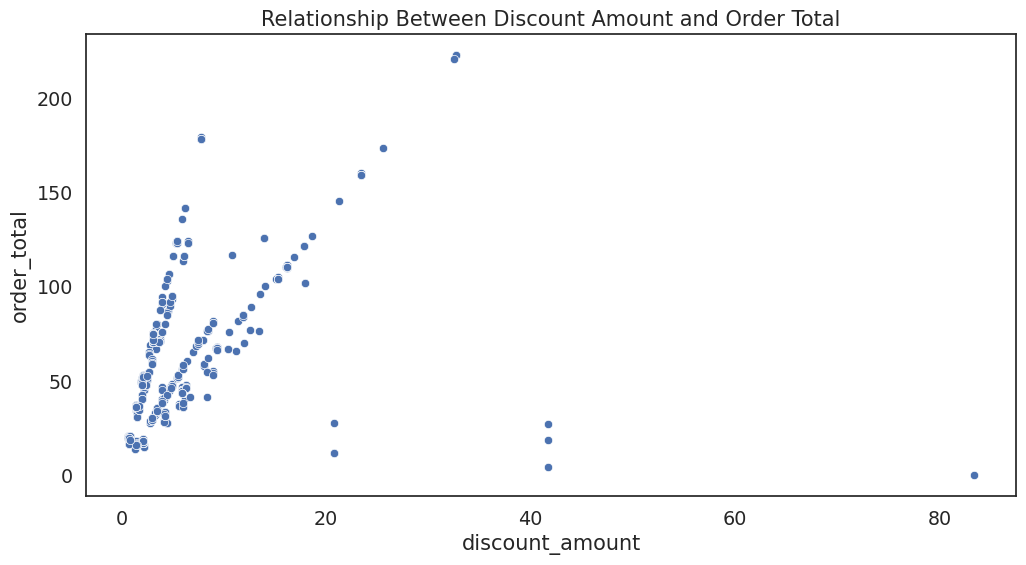

In [29]:
sns.scatterplot(orders, x='discount_amount', y='order_total')
plt.title('Relationship Between Discount Amount and Order Total')

In [30]:
# Discount percentages
#Percentage = (Original Price - Sale Price) / Original Price * 100
orders['discount_percent'] = (orders['discount_amount'] / (orders['order_subtotal']+orders['order_total_tax']+orders['order_shipping'])) * 100
orders['discount_percent'] = orders['discount_percent'].fillna(0)

#print(orders['discount_percent'])

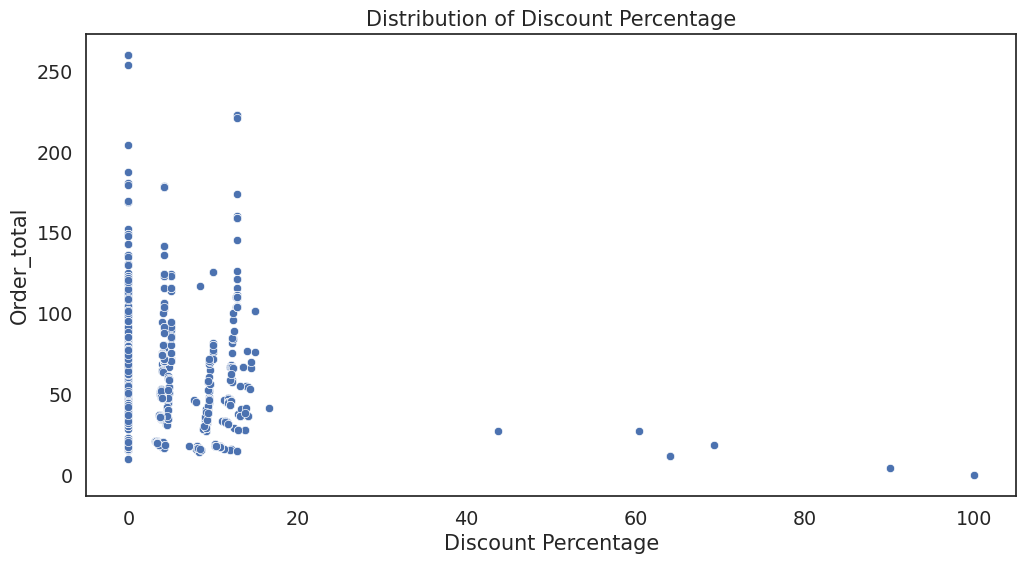

In [31]:
sns.scatterplot(orders, x='discount_percent', y='order_total')
plt.title('Distribution of Discount Percentage')
plt.xlabel('Discount Percentage')
plt.ylabel('Order_total')
plt.show()

In [32]:
# Unusually high spenders (top 1%)
high_spenders = orders[orders['order_total'] > orders['order_total'].quantile(0.99)]
print("High spenders:")
print(high_spenders[['customer_email', 'order_total']].head(10))

# Orders with high discounts but low totals
unusual_discounts = orders[
    (orders['discount_amount'] > 40) & (orders['order_total'] < 30)
]
print("\nUnusual discounts (high amount, low total):")
print(unusual_discounts[['order_id', 'discount_amount', 'order_total']].head())

# Orders with unusually high discount percentages (e.g., > 50%)
unusual_discount_percentages = orders[orders['discount_percent'] > 50]
print("\nOrders with unusually high discount percentages (> 50%):")
print(unusual_discount_percentages[['order_id', 'discount_percent', 'order_total']].head())

High spenders:
                      customer_email  order_total
339   eml_0d507f29@gmail.example.net       152.10
345   eml_0d61ab82@gmail.example.net       169.00
768   eml_1eb3d504@gmail.example.net       178.13
878   eml_22e6c517@gmail.example.net       143.10
915   eml_241dfe95@gmail.example.net       136.20
1268  eml_31a7c7c4@gmail.example.net       222.70
1357  eml_34cf5a03@gmail.example.net       259.80
1410  eml_368cf961@gmail.example.net       180.70
1503  eml_39e8e87b@gmail.example.net       159.38
1517  eml_3a8fe8ee@gmail.example.net       149.00

Unusual discounts (high amount, low total):
          order_id  discount_amount  order_total
4     ord_4163c4a9            41.67         27.4
1534  ord_3be09b0d            83.33          0.0
3622  ord_a4894a0f            41.67         18.5
4085  ord_0624ccb8            41.67          4.6

Orders with unusually high discount percentages (> 50%):
          order_id  discount_percent  order_total
4     ord_4163c4a9         60.338836 

# PyCaret

##Liner regression `order_total`

In [33]:
orders.shape

(6177, 27)

In [34]:
orders.head()

,order_id,customer_email,order_date,payment_method_title,shipping_method_title,coupon_code,coupon_count,origin,order_subtotal,order_total,...,order_total_log,discount_amount_cleaned,discount_amount_tax_cleaned,coupon_code_cleaned,order_month,repeat_order,coupon_used,order_type,spend_segment,discount_percent
0,ord_c14846d3,eml_00036aa8@gmail.example.net,2024-08-24,Cash on delivery,Courier,NaN,0,Facebook,14.08,21.8,...,3.081910,0.00,0.00,non-coupon,2024-08-01,False,No coupon,First,Low (<$50),0.000000
1,ord_af1d680a,eml_00036aa8@gmail.example.net,2024-09-03,Cash on delivery,Courier,NaN,0,Facebook,39.75,52.6,...,3.962716,0.00,0.00,non-coupon,2024-09-01,True,No coupon,Repeat,Medium ($50–$150),0.000000
2,ord_2918d571,eml_00058834@gmail.example.net,2024-06-22,Online payment,Courier,NaN,0,Facebook,39.75,51.2,...,3.935740,0.00,0.00,non-coupon,2024-06-01,False,No coupon,First,Medium ($50–$150),0.000000
3,ord_45bc3ed0,eml_0007e29e@gmail.example.net,2024-04-11,Cash on delivery,Courier (free),NaN,0,Google,74.80,75.8,...,4.328098,0.00,0.00,non-coupon,2024-04-01,False,No coupon,First,Medium ($50–$150),0.000000
4,ord_4163c4a9,eml_0015f5b8@gmail.example.net,2024-10-20,Online payment,Pick-up Point,ROOSTER,1,Google,62.08,27.4,...,3.310543,41.67,8.33,ROOSTER,2024-10-01,False,Coupon,First,Low (<$50),60.338836


In [35]:
#Prepare data for predictions



orders_dataset = orders.sample(frac=0.9, random_state=789).reset_index(drop=True)
orders_unseen = orders.drop(orders_dataset.index).reset_index(drop=True)

print('Data for Modeling: ' + str(orders_dataset.shape))
print('Unseen Data For Predictions: ' + str(orders_unseen.shape))

Data for Modeling: (5559, 27)
Unseen Data For Predictions: (618, 27)


In [36]:
from pycaret.regression import *



#setup(data=orders_dataset, target="order_total", session_id=123, ignore_features=['order_id', 'customer_email'])
setup(data=orders_dataset, target="order_total", session_id=123, ignore_features=['order_id', 'customer_email','coupon_code'])

,Description,Value
0,Session id,123
1,Target,order_total
2,Target type,Regression
3,Original data shape,"(5559, 27)"
4,Transformed data shape,"(5559, 68)"
5,Transformed train set shape,"(3891, 68)"
6,Transformed test set shape,"(1668, 68)"
7,Ignore features,3
8,Numeric features,13
9,Date features,2


In [37]:
#compare_models()
#model = create_model('lr')
compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lr,Linear Regression,0.1282,0.0366,0.1911,0.9999,0.0071,0.0043,0.8410
br,Bayesian Ridge,0.1280,0.0365,0.1910,0.9999,0.0070,0.0043,0.1880
ridge,Ridge Regression,0.1279,0.0365,0.1909,0.9999,0.0070,0.0043,0.1800
omp,Orthogonal Matching Pursuit,0.3404,0.1515,0.3891,0.9998,0.0132,0.0105,0.3570
huber,Huber Regressor,0.6011,0.6783,0.8138,0.9990,0.0349,0.0181,0.4520
dt,Decision Tree Regressor,0.0620,0.9208,0.6309,0.9988,0.0268,0.0011,0.1890
gbr,Gradient Boosting Regressor,0.0959,1.0054,0.6178,0.9987,0.0281,0.0023,0.7150
en,Elastic Net,0.7596,0.9391,0.9661,0.9986,0.0390,0.0226,0.1940
llar,Lasso Least Angle Regression,0.8007,1.0809,1.0336,0.9984,0.0414,0.0236,0.2540
lasso,Lasso Regression,0.8007,1.0805,1.0334,0.9984,0.0414,0.0236,0.2380


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

LinearRegression(n_jobs=-1)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.1225,0.0336,0.1833,1.0000,0.0065,0.0040
1,0.1348,0.0383,0.1957,0.9999,0.0072,0.0045
2,0.1227,0.0351,0.1875,0.9999,0.0067,0.0041
3,0.1288,0.0378,0.1945,0.9999,0.0074,0.0045
4,0.1282,0.0349,0.1869,0.9999,0.0062,0.0041
5,0.1314,0.0366,0.1913,0.9999,0.0073,0.0046
6,0.1390,0.0417,0.2041,0.9999,0.0076,0.0046
7,0.1178,0.0322,0.1794,1.0000,0.0061,0.0038
8,0.1241,0.0353,0.1880,0.9999,0.0069,0.0041


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

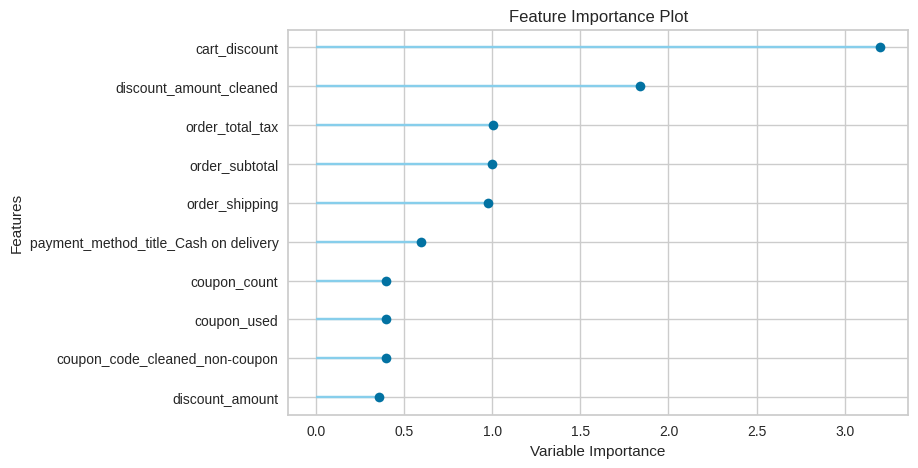

In [38]:
model_lr = create_model('lr')
plot_model(model_lr, plot='feature')

In [39]:
# Make predictions

predictions = predict_model(model_lr, data=orders)
actual_vs_predicted = predictions[['order_total', 'prediction_label','coupon_used']]

actual_vs_predicted.sample(10)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.1261,0.0358,0.1893,0.9999,0.0069,0.0042


,order_total,prediction_label,coupon_used
1480,39.400002,39.346097,No coupon
5901,36.009998,36.201075,Coupon
3416,125.639999,125.534758,Coupon
552,50.220001,50.204227,Coupon
43,50.200001,50.178458,No coupon
3420,21.400000,21.375599,No coupon
748,34.610001,34.617916,Coupon
1066,18.559999,18.504868,Coupon
1846,18.400000,18.396085,No coupon
4778,19.400000,19.310823,No coupon


In [40]:
#Predict on unseen data

unseen_predictions = predict_model(model_lr, data=orders_unseen)
#unseen_predictions.head()


unseen_predictions[['order_total', 'prediction_label', 'coupon_used']].sample(10)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Linear Regression,0.1223,0.0344,0.1855,0.9999,0.0069,0.0042


,order_total,prediction_label,coupon_used
548,17.400000,17.138429,No coupon
334,19.400000,19.293655,No coupon
252,74.500000,74.432128,No coupon
464,48.220001,48.249295,Coupon
581,36.009998,35.874925,Coupon
429,18.270000,18.433716,Coupon
11,50.599998,50.607081,No coupon
155,36.299999,36.212633,No coupon
475,50.200001,50.185388,No coupon
583,36.009998,36.052443,Coupon


In [41]:
final_lr = finalize_model(model_lr)
#print(final_lr)

In [42]:
#Saving model
save_model(final_lr,'Final liner order total Model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('date_feature_extractor',
                  TransformerWrapper(include=['order_date', 'order_month'],
                                     transformer=ExtractDateTimeFeatures())),
                 ('numerical_imputer',
                  TransformerWrapper(include=['coupon_count', 'order_subtotal',
                                              'order_total_tax',
                                              'order_shipping', 'order_refund',
                                              'cart_discount', 'discount_amount',
                                              'discount_amount_t...
                  TransformerWrapper(include=['payment_method_title',
                                              'shipping_method_title', 'origin',
                                              'coupon_code_cleaned',
                                              'spend_segment'],
                                     transformer=OneHotEncoder(c

##Logistic regression `repeat_order01`

In [43]:
# create new variable for repeat_order and change False = 0, True = 1
#orders['repeat_order01'] = orders['repeat_order'].map({False: 0, True: 1})

In [44]:
#orders_customers.head()
orders.head()

,order_id,customer_email,order_date,payment_method_title,shipping_method_title,coupon_code,coupon_count,origin,order_subtotal,order_total,...,order_total_log,discount_amount_cleaned,discount_amount_tax_cleaned,coupon_code_cleaned,order_month,repeat_order,coupon_used,order_type,spend_segment,discount_percent
0,ord_c14846d3,eml_00036aa8@gmail.example.net,2024-08-24,Cash on delivery,Courier,NaN,0,Facebook,14.08,21.8,...,3.081910,0.00,0.00,non-coupon,2024-08-01,False,No coupon,First,Low (<$50),0.000000
1,ord_af1d680a,eml_00036aa8@gmail.example.net,2024-09-03,Cash on delivery,Courier,NaN,0,Facebook,39.75,52.6,...,3.962716,0.00,0.00,non-coupon,2024-09-01,True,No coupon,Repeat,Medium ($50–$150),0.000000
2,ord_2918d571,eml_00058834@gmail.example.net,2024-06-22,Online payment,Courier,NaN,0,Facebook,39.75,51.2,...,3.935740,0.00,0.00,non-coupon,2024-06-01,False,No coupon,First,Medium ($50–$150),0.000000
3,ord_45bc3ed0,eml_0007e29e@gmail.example.net,2024-04-11,Cash on delivery,Courier (free),NaN,0,Google,74.80,75.8,...,4.328098,0.00,0.00,non-coupon,2024-04-01,False,No coupon,First,Medium ($50–$150),0.000000
4,ord_4163c4a9,eml_0015f5b8@gmail.example.net,2024-10-20,Online payment,Pick-up Point,ROOSTER,1,Google,62.08,27.4,...,3.310543,41.67,8.33,ROOSTER,2024-10-01,False,Coupon,First,Low (<$50),60.338836


In [45]:
orders_customers['coupon_used'] = orders['coupon_used']

In [46]:
#Prepare data for predictions

orders_customers['repeat_order01'] = orders_customers['repeat_order'].map({False: 0, True: 1})

orders_dataset_logistic = orders_customers.sample(frac=0.9, random_state=789).reset_index(drop=True)
orders_unseen_logistic = orders_customers.drop(orders_dataset_logistic.index).reset_index(drop=True)

print('Data for Modeling: ' + str(orders_dataset_logistic.shape))
print('Unseen Data For Predictions: ' + str(orders_unseen_logistic.shape))

Data for Modeling: (5559, 29)
Unseen Data For Predictions: (618, 29)


In [47]:
#from pycaret.classification import *

#setup(data=orders[['repeat_order', 'order_total']], target="repeat_order", session_id=123, ignore_features=['order_id', 'customer_email','coupon_code'])
#test_lr = create_model("lr")
#_ = predict_model(test_lr)

In [48]:
orders_dataset_logistic.sample(10)


,order_id,customer_email,order_date,payment_method_title,shipping_method_title,coupon_code,coupon_count,origin,order_subtotal,order_total,...,discount_amount_tax_cleaned,coupon_code_cleaned,order_month,repeat_order,customer_total_orders,customer_total_spent,customer_first_order_date,customer_last_order_date,coupon_used,repeat_order01
2086,ord_e98da871,eml_92db8d00@gmail.example.net,2024-06-07,Online payment,Pick-up Point,NaN,0,Direct,14.08,19.40,...,0.00,non-coupon,2024-06-01,False,1,19.40,2024-06-07,2024-06-07,No coupon,0
3433,ord_a5cdf6b8,eml_daf5db73@gmail.example.net,2024-06-19,Online payment,Pick-up Point,NaN,0,Referral,14.08,19.40,...,0.00,non-coupon,2024-06-01,False,1,19.40,2024-06-19,2024-06-19,No coupon,0
3578,ord_4a10a72d,eml_41697db6@gmail.example.net,2024-06-06,Cash on delivery,Courier,NaN,0,Facebook,14.08,21.40,...,0.00,non-coupon,2024-06-01,False,1,21.40,2024-06-06,2024-06-06,No coupon,0
5311,ord_e8a53b40,eml_917e45fa@gmail.example.net,2024-10-13,Cash on delivery,Pick-up Point,ROOSTER15,1,Referral,28.16,32.63,...,0.84,ROOSTER15,2024-10-01,False,1,32.63,2024-10-13,2024-10-13,Coupon,0
4893,ord_01df593c,eml_9be7d39d@gmail.example.net,2024-04-16,Cash on delivery,Pick-up Point,ROOSTER5,1,Referral,47.70,47.82,...,0.00,ROOSTER5,2024-04-01,False,1,47.82,2024-04-16,2024-04-16,Coupon,0
726,ord_892baafa,eml_212faef1@gmail.example.net,2024-04-11,Online payment,Pick-up Point,NaN,0,Referral,47.70,50.20,...,0.00,non-coupon,2024-04-01,True,2,82.50,2024-03-24,2024-04-11,No coupon,1
1155,ord_c6775b13,eml_f2323479@gmail.example.net,2024-06-20,Cash on delivery,Pick-up Point,NaN,0,Unknown,28.16,37.30,...,0.00,non-coupon,2024-06-01,False,1,37.30,2024-06-20,2024-06-20,No coupon,0
3152,ord_b6edf490,eml_a7dc80ae@gmail.example.net,2024-06-12,Online payment,Pick-up Point,NaN,0,Google,28.16,36.30,...,0.00,non-coupon,2024-06-01,False,1,36.30,2024-06-12,2024-06-12,No coupon,0
1909,ord_b3c994c6,eml_600d0413@gmail.example.net,2024-07-12,Online payment,Courier,NaN,0,Facebook,56.32,71.10,...,0.00,non-coupon,2024-07-01,False,1,71.10,2024-07-12,2024-07-12,No coupon,0
4082,ord_7e74b694,eml_0751a66d@gmail.example.net,2024-03-11,Cash on delivery,Courier,ROOSTER5,1,Direct,29.80,32.81,...,0.00,ROOSTER5,2024-03-01,False,1,32.81,2024-03-11,2024-03-11,Coupon,0


In [49]:
# test PyCaret: run a simple classification model to predict repeat orders based on order_total

from pycaret.classification import *

setup(data=orders_dataset_logistic, target="repeat_order01", verbose=False, ignore_features=['order_id', 'customer_email','coupon_code','repeat_order','order_seq','customer_total_orders'])

#[['repeat_order01','order_total','customer_total_orders','customer_total_spent','customer_first_order_date','customer_last_order_date','coupon_used','payment_method_title,']]
#test_lr = create_model("lr", verbose=False)
#_ = predict_model(test_lr)

#setup(data=orders_dataset_logistic, target="repeat_order01", session_id=123, ignore_features=['order_id', 'customer_email','coupon_code','repeat_order'])

In [50]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9879,0.9983,0.9361,0.9956,0.9646,0.9573,0.9582,0.4090
gbc,Gradient Boosting Classifier,0.9707,0.9941,0.8461,0.9863,0.9102,0.8929,0.8970,1.0640
rf,Random Forest Classifier,0.9388,0.9803,0.7198,0.9166,0.8062,0.7706,0.7786,0.5800
knn,K Neighbors Classifier,0.9301,0.9588,0.7678,0.8284,0.7940,0.7522,0.7549,0.1940
dt,Decision Tree Classifier,0.9275,0.8677,0.7750,0.8093,0.7907,0.7469,0.7479,0.3950
et,Extra Trees Classifier,0.9203,0.9567,0.6327,0.8851,0.7371,0.6918,0.7058,0.6080
lda,Linear Discriminant Analysis,0.9154,0.9629,0.5893,0.9034,0.7097,0.6631,0.6857,0.1820
ridge,Ridge Classifier,0.9116,0.9634,0.5428,0.9325,0.6822,0.6355,0.6688,0.1610
ada,Ada Boost Classifier,0.9103,0.9439,0.6328,0.8217,0.7143,0.6621,0.6705,0.3910
lr,Logistic Regression,0.9044,0.9114,0.5733,0.8375,0.6793,0.6255,0.6418,0.6020


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cpu', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=-1, num_parallel_tree=None, ...)

In [51]:
model_logistic= create_model('lr')
#preds = predict_model(model_logistic)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8872,0.8963,0.4928,0.7907,0.6071,0.5454,0.5662
1,0.8997,0.9032,0.5882,0.7843,0.6723,0.6145,0.6234
2,0.8946,0.9299,0.5507,0.7917,0.6496,0.5899,0.6033
3,0.9023,0.8784,0.6087,0.7925,0.6885,0.6318,0.6395
4,0.9280,0.9406,0.6232,0.9556,0.7544,0.7144,0.7368
5,0.8843,0.9234,0.5217,0.7500,0.6154,0.5499,0.5624
6,0.9280,0.9647,0.6522,0.9184,0.7627,0.7217,0.7364
7,0.9075,0.8668,0.5217,0.9231,0.6667,0.6177,0.6516
8,0.9152,0.9187,0.6377,0.8462,0.7273,0.6782,0.6877


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

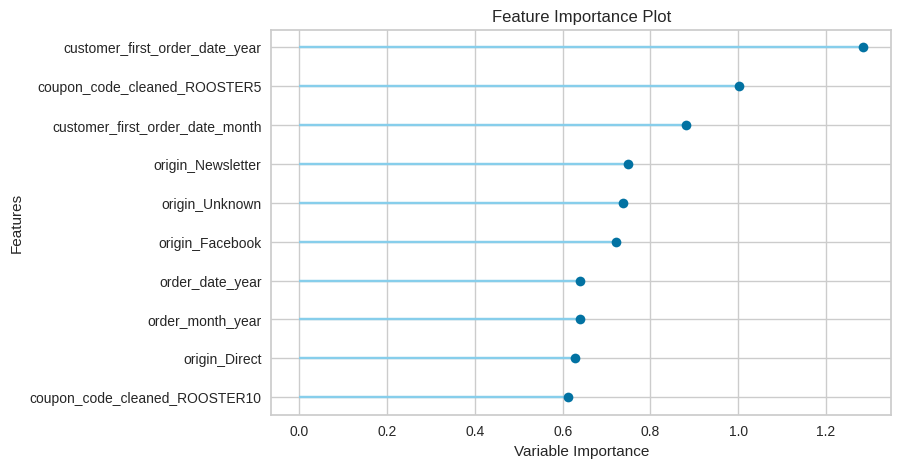

In [52]:
plot_model(model_logistic, plot='feature')

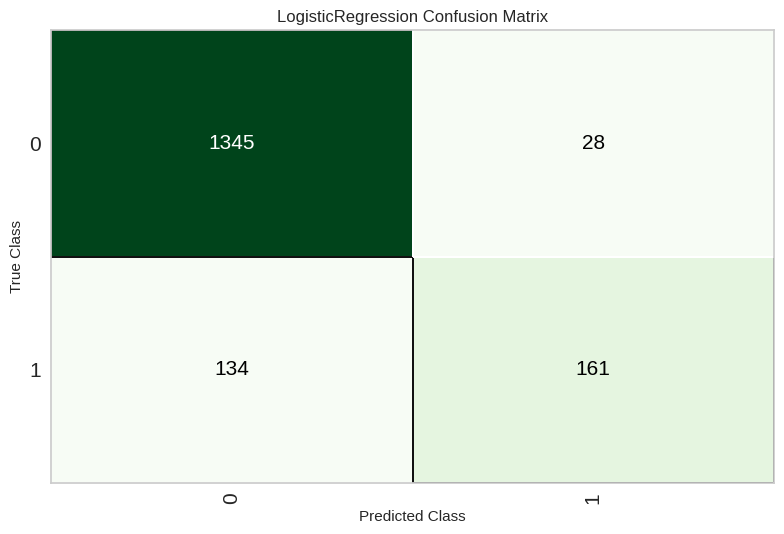

In [53]:
# plot confusion matrix

plot_model(model_logistic, plot='confusion_matrix')

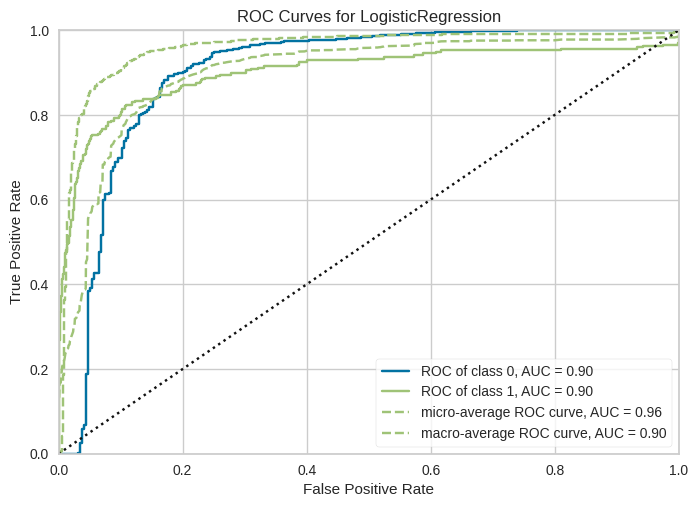

In [54]:
plot_model(model_logistic, plot='auc')  # ROC curve

In [55]:
#evaluate_model(model_logistic)

predictions = predict_model(model_logistic)
#predictions = predict_model(model_logistic, data=orders_dataset_logistic)

predictions[['repeat_order01', 'prediction_label', 'prediction_score']].sample(10)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9029,0.9000,0.5458,0.8519,0.6653,0.6116,0.6324


,repeat_order01,prediction_label,prediction_score
2119,0,0,0.9444
5527,0,0,0.9400
2287,1,0,0.5100
2361,0,0,0.9760
3540,0,0,0.9424
3009,0,0,0.7927
1191,0,0,0.9931
1463,1,1,0.9987
1362,0,0,0.9846
4382,0,0,0.9621


In [56]:
##unseen_predictions = predict_model(model_logistic, data=orders_unseen_logistic)

#predictions[['repeat_order01', 'prediction_label', 'prediction_score']].sample(10)

In [57]:
#Saving model
final_logistic = finalize_model(model_logistic)
save_model(final_logistic,'Final logistic regression order total Model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('date_feature_extractor',
                  TransformerWrapper(exclude=None,
                                     include=['order_date', 'order_month',
                                              'customer_first_order_date',
                                              'customer_last_order_date'],
                                     transformer=ExtractDateTimeFeatures(features=['day',
                                                                                   'month',
                                                                                   'year']))),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['coupon_count', 'order_...
                                                               handle_missing='return_nan',
                                                               handle_unknown='value',
                     

##